# TrAIn.me – Expérience NLP avec Transformer sous PyTorch  
## Construire un Modèle Transformer Capable de Générer du Texte Sportif

## Objectifs de ce notebook

Dans ce notebook, nous allons développer un **modèle Transformer** en **PyTorch** afin de générer du texte cohérent dans le contexte du projet **TrAIn.me**.  
L’objectif est d’établir une **baseline Transformer minimale** sous PyTorch (compatible déploiement HuggingFace), avant d’explorer des variantes plus avancées.

Voici les axes que nous allons couvrir :

1. **Préparation du corpus TrAIn.me**  
   Nettoyage, normalisation et segmentation du texte fitness (échauffements, conseils, exercices, finishers…).

2. **Tokenisation & séquences supervisées**  
   Transformation du corpus en un jeu d’apprentissage adapté au Transformer : vocabulaire, encodage, séquences input–target.

3. **Architecture Transformer sous PyTorch**  
   Embedding → Positional Encoding → Multi-Head Self-Attention → Feed-Forward.  
   Un modèle compact et lisible pour capturer les dépendances globales.

4. **Boucle d’entraînement PyTorch**  
   Optimiseur, loss cross-entropy, masquage causal et entraînement batch par batch.

5. **Génération de texte autoregressive**  
   Test de génération à partir de seeds thématiques :
   - Workout [strength]  
   - Workout [cardio]  
   - Workout [mobility]

6. **Baseline du Labo DL–NLP**  
   Ce modèle constitue le point de comparaison pour les futures variantes :
   - Transformer plus profond  
   - GPT-like simplifié  
   - Modèles pré-entraînés

## Concepts clés abordés

- Tokenisation custom et préparation de séquences supervisées.  
- Embeddings + encodage positionnel pour gérer l’ordre des tokens.  
- Mécanisme **Self-Attention** et **Multi-Head Attention**.  
- Génération autoregressive avec température / top-p.  
- Export PyTorch `.pt` / `.bin` compatible HuggingFace Spaces.

Ce travail marque la continuité de la migration vers un pipeline **100% PyTorch**, parfaitement compatible avec le déploiement de l’application TrAIn.me.


## 1. Installation et configuration de l’environnement

Dans cette première section, nous préparons un environnement **Windows** basé sur **PyTorch** pour entraîner un modèle **Transformer** appliqué au NLP dans le cadre de **TrAIn.me**.

L’objectif est de mettre en place un socle technique propre et reproductible pour :

- détecter automatiquement la présence d’un **GPU CUDA** (si disponible), ou basculer proprement sur le **CPU** ;
- charger les bibliothèques essentielles : `torch`, `torch.nn`, `torch.utils.data`, ainsi que `pandas`, `numpy`, `matplotlib`, et les utilitaires nécessaires au prétraitement ;
- fixer une **seed globale** afin de garantir la reproductibilité du tokeniseur, des embeddings et des séquences utilisées pour l’apprentissage ;
- appliquer un style graphique cohérent pour le suivi de la loss et des performances durant l’entraînement.

À l’issue de cette cellule, l’environnement est prêt pour :
- charger le corpus TrAIn.me,
- générer les séquences supervisées adaptées au Transformer,
- initialiser le modèle (Embedding → Positional Encoding → Multi-Head Attention → Feed-Forward),
- lancer l’entraînement et la génération autoregressive sous PyTorch,
- visualiser la loss et analyser la dynamique d’apprentissage du modèle.


## Imports

In [ ]:
# Bibliothèques principales
import re
from pathlib import Path
import platform
import random
from pathlib import Path
import json
from datetime import datetime
import warnings
from collections import Counter

# Visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import kagglehub

# PyTorch & HuggingFace (version Transformers pour la distillation GPT-2)
import torch
import torch.nn as nn
from torch.utils.data import  DataLoader
import transformers

## Configuration

### Configuration GPU

In [33]:
warnings.filterwarnings("ignore")

# --- Infos système ---
print("TrAIn.me — Environnement Windows (PyTorch / Transformers)\n")
print(f"Système      : {platform.system()} {platform.release()}")
print(f"Architecture : {platform.machine()}")

# --- GPU / CPU ---
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"\nGPU détecté : {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("\nAucun GPU CUDA détecté — utilisation du CPU (plus lent)")

TrAIn.me — Environnement Windows (PyTorch / Transformers)

Système      : Windows 10
Architecture : AMD64

Aucun GPU CUDA détecté — utilisation du CPU (plus lent)


### Configuration graphiques

In [34]:
# # Style “Dark Neon” (effet LLM / DL moderne)
# plt.style.use("dark_background")
# sns.set_palette("bright")

# Deep Blue Modern
plt.style.use("bmh")  # base propre et structurée
sns.set_palette(["#1f78b4", "#33aaff", "#88ccee", "#004c99"])

# # Violet Fusion
# plt.style.use("seaborn-v0_8-dark")
# sns.set_palette(["#6A0DAD", "#A56EDE", "#CBA6F7", "#3D0066"])

# # Mint & Carbon
# plt.style.use("dark_background")
# sns.set_palette(["#7FFFD4", "#3DE1B0", "#2BC4A5", "#1FA58C"])

# # Warm Gradient
# plt.style.use("ggplot")
# sns.set_palette(["#FF7F50", "#FF9966", "#FFB380", "#FFD2B3"])

# # Techno Red Pulse
# plt.style.use("dark_background")
# sns.set_palette(["#FF1744", "#FF4569", "#FF7A8A", "#FFB3C1"])


### Header expérimental

In [35]:
# --- Reproductibilité complète ---
SEED_GLOBAL = 42
random.seed(SEED_GLOBAL)
np.random.seed(SEED_GLOBAL)
torch.manual_seed(SEED_GLOBAL)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED_GLOBAL)

OUTPUT_MODEL_NAME = "transformer_v2"

# Hyperparamètres modèles
EMBED_DIM = 64
NUM_HEADS = 8
FF_DIM = 512
NUM_BLOCKS = 3
LEARNING_RATE = 1e-4

# Dataset & entraînement
BATCH_SIZE = 16
EPOCHS = 1

MAX_SEQ_LEN = 512  # ou 512 si tu veux tester plus large


### Affichage des versions d'imports

In [36]:
print("\nVersions utilisées :")
print(f"  - torch        : {torch.__version__}")
print(f"  - transformers : {transformers.__version__}")
print("  - datasets     : installé (HuggingFace Datasets)")
print("\nEnvironnement configuré — prêt pour la distillation GPT-2 spécialisée TrAIn.me !")


Versions utilisées :
  - torch        : 2.9.1+cpu
  - transformers : 4.57.3
  - datasets     : installé (HuggingFace Datasets)

Environnement configuré — prêt pour la distillation GPT-2 spécialisée TrAIn.me !


## 2. Chargement et Préparation du Corpus TrAIn.me

Dans cette section, nous chargeons et préparons le **corpus textuel TrAIn.me**, qui contient des exemples de contenus sportifs :
- échauffements,
- séances strength / cardio / mobility,
- descriptions d’exercices,
- conseils techniques,
- finishers et routines courtes.

Ce corpus servira de base pour :
- l’apprentissage supervisé des séquences Transformer,
- la génération autoregressive en fin d’entraînement,
- l’évaluation qualitative des sorties du modèle.

L’objectif principal est de transformer ce corpus en un format directement exploitable par un Transformer PyTorch :
- nettoyage léger (espaces superflus, retours ligne, ponctuation incohérente),
- segmentation éventuelle en phrases ou blocs cohérents,
- tokenisation custom (vocabulaire sportif construit à partir du corpus),
- création des **séquences input–target** nécessaires à l’apprentissage autoregressif.

Une fois cette étape effectuée, nous pourrons générer un dataset PyTorch propre, prêt à alimenter le modèle Transformer pour l’étape suivante : entraînement et génération de texte.


### 2.1. Concaténation des corpus

In [ ]:
print("Chargement du corpus TrAIn.me (program_summary.csv)...\n")

# Téléchargement automatique du dataset Kaggle
path = kagglehub.dataset_download(
    "adnanelouardi/600k-fitness-exercise-and-workout-program-dataset"
)

print("Dataset téléchargé avec succès !")
print("Chemin local :", path, "\n")

# Conversion du chemin KaggleHub → Path
dataset_dir = Path(path)

# Fichier CSV principal (structure confirmée dans le dataset Kaggle)
csv_path = dataset_dir / "program_summary.csv"

print(f"Lecture du fichier : {csv_path.name}\n")

# Chargement du corpus fusionné
df = pd.read_csv(csv_path)

print("Corpus chargé avec succès !\n")
print("Aperçu du corpus :")
print(df.head())

print("\nInformations générales :")
print(f"  - Nombre total d’entrées : {len(df)}")
print(f"  - Colonnes disponibles    : {list(df.columns)}")

# Sélection des colonnes textuelles à utiliser pour le Transformer
# → tu ajustes cette liste selon la structure réelle de program_summary.csv
candidate_text_cols = ["text", "program_text", "description", "exercises", "notes"]
text_columns = [c for c in candidate_text_cols if c in df.columns]

if not text_columns:
    # fallback : toutes les colonnes de type "object" (texte)
    text_columns = [c for c in df.columns if df[c].dtype == "object"]

print("\nColonnes textuelles utilisées pour construire le corpus :")
print(f"  - {text_columns}")

# Construction d'une liste de textes à partir des colonnes retenues
corpus_texts = []
for _, row in df[text_columns].iterrows():
    # On concatène les différentes colonnes textuelles ligne par ligne
    parts = [str(v).strip() for v in row.values if isinstance(v, str) and v.strip()]
    if parts:
        corpus_texts.append("\n".join(parts))

print(f"\nNombre de segments textuels retenus : {len(corpus_texts)}")

# Concaténation globale pour le POC Transformer
# → le Transformer utilisera ensuite une tokenisation + découpage en séquences
full_text = "\n\n".join(
    t.strip() for t in corpus_texts
    if t and isinstance(t, str)
)

print("\nRésumé du corpus concaténé :")
print(f"  - Longueur totale (caractères) : {len(full_text)}")
print("  - Aperçu (500 premiers caractères) :\n")
print(full_text[:500])


Chargement du corpus TrAIn.me (program_summary.csv)...

Corpus chargé avec succès !

Aperçu du corpus :
                                               title  \
0  (MASS MONSTER) High Intensity 4 Day Upper Lowe...   
1                         (NOT MY PROGRAM)SHJ Jotaro   
2  1 PowerLift Per Day Powerbuilding 5 Day Bro Split   
3                      10 Week Mass Building Program   
4                             10 week deadlift focus   

                                         description  \
0  Build tones of muscular with this high intensi...   
1                            Build strength and size   
2  Based off of Andy Baker's KCS (Kingwood Streng...   
3  This workout is designed to increase your musc...   
4                                  Increase deadlift   

                                    level  \
0                        ['Intermediate']   
1            ['Advanced', 'Intermediate']   
2  ['Beginner', 'Novice', 'Intermediate']   
3            ['Intermediate', 'Advanced'] 

### 4.2. Vérifications du corpus

Avant de passer à la tokenisation et à la création des séquences pour le modèle Transformer, nous effectuons une série de contrôles rapides afin de valider la qualité du corpus extrait depuis `program_summary.csv`.

Ces vérifications permettent de :

- confirmer que le texte a bien été concaténé ;
- estimer la taille du corpus (caractères, mots, lignes) ;
- visualiser un extrait brut du contenu ;
- inspecter quelques exemples aléatoires provenant des différentes lignes du CSV.

Ces contrôles garantissent que l’entrée textuelle est suffisamment propre et volumineuse pour entraîner efficacement un modèle Transformer en PyTorch.


In [38]:
### Vérifications du corpus

print("\n=== Vérifications du corpus Transformer TrAIn.me ===\n")

# Taille brute du texte
print(f"Longueur totale du corpus (caractères) : {len(full_text)}")

# Quelques statistiques simples
nb_lignes = full_text.count("\n")
nb_mots = len(full_text.split())

print(f"Nombre approximatif de lignes : {nb_lignes}")
print(f"Nombre approximatif de mots   : {nb_mots}")

# Aperçu du contenu
print("\n--- Exemple brut du corpus (300 premiers caractères) ---\n")
print(full_text[:300])

# Vérification de segments aléatoires
import random

print("\n--- Exemples aléatoires du corpus ---\n")
for i in range(3):
    idx = random.randint(0, len(corpus_texts) - 1)
    extrait = corpus_texts[idx][:200].replace("\n", " ")
    print(f"[{i+1}] {extrait}...")



=== Vérifications du corpus Transformer TrAIn.me ===

Longueur totale du corpus (caractères) : 777001
Nombre approximatif de lignes : 13033
Nombre approximatif de mots   : 130585

--- Exemple brut du corpus (300 premiers caractères) ---

Build tones of muscular with this high intensity 4 day upper lower workout routine.

Weekly Setup:
Day 1 - Upper Push Focus
Day 2 - Lower Quad Focus
Day 3 - Rest/Active Recovery
Day 4 - Upper Pull Focus
Day 5 - Rest/Active Recovery
Day 6 - Lower Hamstring Focus
Day 7 - Rest/Active Recovery 

Muscle 

--- Exemples aléatoires du corpus ---

[1] Beginner friendly simple...
[2] Overload Overload is critical to the muscle building process. Push each set for the maximum number of reps, stopping that set either when you feel your form is slipping, or if you feel like you may fa...
[3] To push you to the limits and not hold back one bit...


### 4.3. Prétraitement du texte

Dans cette partie, nous appliquons un **prétraitement léger** au corpus TrAIn.me afin de le rendre exploitable par notre **POC Transformer word-level** sous PyTorch.

L’objectif est de rester cohérent avec les autres expériences du Labo DL–NLP :

- POC LSTM word-level (POC #1 dans le plan),
- POC GRU word-level (POC #2),
- et une future variante Transformer dédiée (par exemple `transformer_train.me.py`) qui réutilisera la même logique de nettoyage.

Ici, nous conservons une approche **word-level** : le texte est normalisé, mais nous évitons les nettoyages trop agressifs pour préserver le vocabulaire sportif et les tournures naturelles.

### Pourquoi la longueur du texte augmente ?

Lors du nettoyage, nous ajoutons des espaces autour de la ponctuation pour faciliter la tokenisation.  
Cela transforme par exemple :

- `musculation,cardio` → `musculation , cardio`  
- `fatigué!continue`   → `fatigué ! continue`  

À chaque ponctuation, on ajoute au moins 1 espace supplémentaire, ce qui **augmente mécaniquement la longueur totale du texte** (en caractères) mais rend la séparation des tokens plus fiable pour la suite (tokenisation, séquences input–target, masques du Transformer).


In [39]:
def clean_text(texte):
    """Nettoie et normalise le texte pour un Transformer word-level."""
    texte = texte.lower()

    # Ajouter des espaces autour de la ponctuation utile
    # (évite la fusion de tokens du type "fatigué!continue")
    texte = re.sub(r"([.,!?])", r" \1 ", texte)

    # Réduire les espaces multiples
    texte = re.sub(r"\s+", " ", texte)

    return texte.strip()


# Nettoyage du corpus Transformer (basé sur corpus_texts)
cleaned_corpus = [clean_text(phrase) for phrase in corpus_texts]

print("Exemples de phrases nettoyées :")
for i in range(3):
    print("\nLongueur avant nettoyage :", len(corpus_texts[i]))
    print(f"Original : {corpus_texts[i]}")
    print("Longueur après nettoyage :", len(cleaned_corpus[i]))
    print(f"Nettoyé  : {cleaned_corpus[i]}")


Exemples de phrases nettoyées :

Longueur avant nettoyage : 449
Original : Build tones of muscular with this high intensity 4 day upper lower workout routine.

Weekly Setup:
Day 1 - Upper Push Focus
Day 2 - Lower Quad Focus
Day 3 - Rest/Active Recovery
Day 4 - Upper Pull Focus
Day 5 - Rest/Active Recovery
Day 6 - Lower Hamstring Focus
Day 7 - Rest/Active Recovery 

Muscle Groups |Sets Per Week
Back - 10
Shoulders - 10
Chest - 9
Quads - 9
Hamstrings - 9
Glutes - 9
Biceps - 7
Triceps - 7
Lower Back - 4
Calves - 4
Abs - 4
Longueur après nettoyage : 447
Nettoyé  : build tones of muscular with this high intensity 4 day upper lower workout routine . weekly setup: day 1 - upper push focus day 2 - lower quad focus day 3 - rest/active recovery day 4 - upper pull focus day 5 - rest/active recovery day 6 - lower hamstring focus day 7 - rest/active recovery muscle groups |sets per week back - 10 shoulders - 10 chest - 9 quads - 9 hamstrings - 9 glutes - 9 biceps - 7 triceps - 7 lower back - 4 calv

### 4.4. Tokenization

La tokenization consiste à convertir le texte nettoyé en **séquences d’identifiants numériques** utilisables par le modèle Transformer.  
Chaque mot est transformé en un entier unique selon un vocabulaire construit à partir du corpus TrAIn.me.

Cette étape est essentielle, car elle permet au modèle d’apprendre :
- les cooccurrences entre mots,
- les dépendances longues capturées par l’attention,
- la structure grammaticale et les patterns propres au domaine sportif.

Une fois le vocabulaire généré, chaque phrase est convertie en une liste d’indices qui servira ensuite à créer les séquences `input → target` nécessaires à l’entraînement autoregressif du Transformer.


In [40]:
print("Construction du tokenizer (word-level minimal)…\n")

# Tokenisation simple : split sur les espaces après nettoyage
tokenized_sentences = [sentence.split() for sentence in cleaned_corpus]

# Compter les fréquences
word_counter = Counter()
for sent in tokenized_sentences:
    word_counter.update(sent)

# Définition des tokens spéciaux
special_tokens = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]

# Construire le vocabulaire (tokens spéciaux en premier)
vocab = special_tokens + sorted(word_counter.keys())

# Dictionnaire mot → id
word2idx = {word: idx for idx, word in enumerate(vocab)}

# Dictionnaire inverse id → mot
idx2word = {idx: word for word, idx in word2idx.items()}

# Taille du vocabulaire
vocab_size = len(vocab)
print(f"Taille du vocabulaire : {vocab_size} mots\n")

# Top 20 mots les plus fréquents
print("Top 20 mots les plus fréquents :\n")
for i, (word, freq) in enumerate(word_counter.most_common(20), 1):
    print(f"{i:2d}. '{word}' : {freq} fois")


Construction du tokenizer (word-level minimal)…

Taille du vocabulaire : 11132 mots

Top 20 mots les plus fréquents :

 1. '.' : 7435 fois
 2. ',' : 5851 fois
 3. 'the' : 4194 fois
 4. 'and' : 4017 fois
 5. 'to' : 3900 fois
 6. 'a' : 2702 fois
 7. 'for' : 2214 fois
 8. 'you' : 2006 fois
 9. 'of' : 1884 fois
10. 'is' : 1681 fois
11. 'program' : 1603 fois
12. 'this' : 1443 fois
13. 'on' : 1395 fois
14. 'with' : 1293 fois
15. 'in' : 1235 fois
16. 'week' : 1193 fois
17. 'strength' : 1020 fois
18. 'your' : 998 fois
19. 'muscle' : 797 fois
20. 'day' : 787 fois


### 4.5 Pourquoi le LSTM nécessite `SEQ_LEN` et pourquoi le Transformer peut fonctionner sans ?

Dans le POC LSTM, nous avions besoin d’un **`SEQ_LEN` fixe** (`MAX_SEQUENCE_LENGTH`) pour construire des fenêtres glissantes de taille constante :
- chaque entrée du batch avait exactement la même longueur,
- le tenseur d’entrée était de forme `(batch_size, SEQ_LEN)`,
- on tronquait ou on complétait les séquences pour respecter cette contrainte.

Pour le POC Transformer word-level présenté ici, nous adoptons une approche différente :  
nous laissons les **séquences croître progressivement** à partir d’un même début, par exemple :
- `[12, 4]`  
- `[12, 4, 33]`  
- `[12, 4, 33, 7]`  
- etc.

Dans cette version expérimentale, le Transformer travaille donc sur des **séquences de longueurs variables**, qui seront ensuite :
- soit **padées dynamiquement** au moment de la création des batches,
- soit traitées avec des masques adaptés lors de l’attention.

En résumé :
- le **LSTM** impose naturellement un `SEQ_LEN` fixe pour ses fenêtres d’apprentissage ;
- le **Transformer**, lui, est plus flexible et peut gérer des longueurs variables, ce qui nous permet ici de nous affranchir d’un `SEQ_LEN` global strict, tout en gardant la possibilité d’en introduire un plus tard pour des raisons de mémoire ou de vitesse d’entraînement.


In [41]:
def prepare_sequences(textes, word2idx, max_seq_len=None):
    """
    Crée des séquences input-output (n-grams progressifs) à partir
    d'un tokenizer word-level dictionnaire {mot → id}.
    """
    sequences = []

    for texte in textes:
        tokens = [word2idx.get(tok, word2idx["<UNK>"]) for tok in texte.split()]

        # Ignore les phrases trop courtes
        if len(tokens) <= 1:
            continue

        # Génération des n-grams progressifs
        for i in range(1, len(tokens)):
            n_gram = tokens[:i+1]

            # Tronquage éventuel
            if max_seq_len is not None and len(n_gram) > max_seq_len:
                n_gram = n_gram[-max_seq_len:]

            sequences.append(n_gram)

    return sequences


# Création des séquences Transformer
sequences = prepare_sequences(
    cleaned_corpus,
    word2idx,
    max_seq_len=MAX_SEQ_LEN  # None si tu veux laisser les longueurs croissantes
)

print(f"\nNombre total de séquences : {len(sequences)}")
print(f"\nExemples de séquences (premiers tokens) :")


# Exemple sur la première phrase
example_sentence = cleaned_corpus[0]
example_tokens = [word2idx.get(tok, word2idx["<UNK>"]) for tok in example_sentence.split()]

print(f"\nPhrase : '{example_sentence}'")
print(f"Tokens : {example_tokens}\n")

# Affichage des 5 premiers n-grams générés
for i in range(1, min(6, len(example_tokens))):
    seq = example_tokens[:i+1]
    words_seq = [idx2word[idx] for idx in seq]

    print(f"  {seq[:-1]} → {seq[-1]} | {words_seq[:-1]} → {words_seq[-1]}")



Nombre total de séquences : 141997

Exemples de séquences (premiers tokens) :

Phrase : 'build tones of muscular with this high intensity 4 day upper lower workout routine . weekly setup: day 1 - upper push focus day 2 - lower quad focus day 3 - rest/active recovery day 4 - upper pull focus day 5 - rest/active recovery day 6 - lower hamstring focus day 7 - rest/active recovery muscle groups |sets per week back - 10 shoulders - 10 chest - 9 quads - 9 hamstrings - 9 glutes - 9 biceps - 7 triceps - 7 lower back - 4 calves - 4 abs - 4'
Tokens : [2687, 10017, 7144, 6885, 10769, 9886, 5274, 5678, 1240, 3489, 10337, 6325, 10811, 8568, 784, 10651, 8884, 3489, 804, 695, 10337, 8038, 4634, 3489, 1031, 695, 6325, 8070, 4634, 3489, 1144, 695, 8444, 8249, 3489, 1240, 695, 10337, 7980, 4634, 3489, 1315, 695, 8444, 8249, 3489, 1413, 695, 6325, 5148, 4634, 3489, 1478, 695, 8444, 8249, 6872, 5054, 10946, 7454, 10627, 2226, 695, 842, 8962, 695, 842, 2945, 695, 1562, 8072, 695, 1562, 5149, 695, 1562, 49

### 4.6. Padding et préparation des tenseurs PyTorch

Dans cette étape, nous transformons les séquences n-grams en tenseurs exploitables par le futur modèle Transformer.  
Comme les séquences ont des longueurs variables, nous appliquons un **padding préfixé** avec le token `<PAD>` (id = 0), ce qui permet d’obtenir un tenseur uniforme.

Les opérations réalisées dans cette cellule :

- détection automatique de la longueur maximale des séquences ;
- padding manuel en tête de séquence (`pre-padding`) pour conserver la cohérence des n-grams ;
- création des tenseurs PyTorch `X` (entrées) et `y` (cibles), où  
  - `X` contient tous les tokens sauf le dernier,  
  - `y` correspond au token à prédire (format entier, compatible `CrossEntropyLoss`) ;
- visualisation de la distribution des longueurs des séquences avant padding.

Cette étape finalise la préparation des données avant la création du `Dataset` PyTorch et de la boucle d’entraînement du Transformer.


Longueur maximale détectée : 512

Dimensions des données :
  X (input)  : torch.Size([141997, 511])  # (nombre_sequences, longueur_sequence-1)
  y (output) : torch.Size([141997])  # (nombre_sequences,) indices de classes

  Longueur maximale de séquence (avec padding) : 512


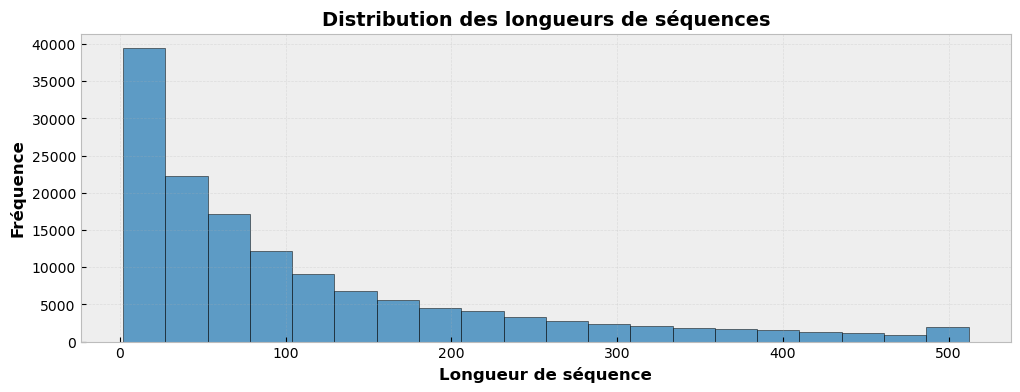

In [42]:
# === Padding des séquences pour le Transformer PyTorch ===
import torch

# Longueur maximale des séquences (en nombre de tokens)
max_sequence_length = max(len(seq) for seq in sequences)

print(f"Longueur maximale détectée : {max_sequence_length}")

# Padding manuel en préfixant avec le token <PAD> (id = 0)
PAD_IDX = word2idx["<PAD>"]

padded_sequences = []
for seq in sequences:
    if len(seq) < max_sequence_length:
        pad_len = max_sequence_length - len(seq)
        padded = [PAD_IDX] * pad_len + seq
    else:
        # Par sécurité, on tronque si jamais une séquence dépasse (cas futur)
        padded = seq[-max_sequence_length:]
    padded_sequences.append(padded)

padded_sequences = torch.tensor(padded_sequences, dtype=torch.long)

# Séparation X (input) et y (output)
X = padded_sequences[:, :-1]  # Tous les tokens sauf le dernier
y = padded_sequences[:, -1]   # Le dernier token (classe cible, entiers)

print(f"\nDimensions des données :")
print(f"  X (input)  : {X.shape}  # (nombre_sequences, longueur_sequence-1)")
print(f"  y (output) : {y.shape}  # (nombre_sequences,) indices de classes")
print(f"\n  Longueur maximale de séquence (avec padding) : {max_sequence_length}")

# Visualisation de la distribution des longueurs (hors padding)
sequence_lengths = (padded_sequences != PAD_IDX).sum(dim=1).tolist()

plt.figure(figsize=(12, 4))
plt.hist(sequence_lengths, bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Longueur de séquence", fontsize=12, fontweight="bold")
plt.ylabel("Fréquence", fontsize=12, fontweight="bold")
plt.title("Distribution des longueurs de séquences", fontsize=14, fontweight="bold")
plt.grid(alpha=0.3)
plt.show()


### 4.7 Construction du dataset séquentiel

Avant de créer le `Dataset` PyTorch destiné au modèle Transformer, nous réalisons un **split train/validation** afin de séparer les séquences destinées à l’apprentissage de celles réservées à l’évaluation.

Ce découpage est essentiel pour :
- mesurer la capacité du Transformer à généraliser,
- suivre la loss de validation au fil des époques,
- détecter le surapprentissage (overfitting),
- ajuster ensuite la taille du modèle ou la régularisation si nécessaire.

La cellule suivante mettra en place ce split, puis construira un `Dataset` PyTorch contenant :
- `X` (séquences d’entrée),
- `y` (token cible à prédire),
- et les longueurs utiles après padding.

Ces objets serviront directement au `DataLoader` et à la boucle d’entraînement du Transformer.


In [43]:
# Conversion vers torch.Tensor
X_tensor = torch.tensor(X, dtype=torch.long)
y_tensor = torch.tensor(y, dtype=torch.long)

# Calcul des tailles
dataset_size = len(X_tensor)
val_size = int(dataset_size * 0.1)   # 10% validation
train_size = dataset_size - val_size

# Split aléatoire reproductible
generator = torch.Generator().manual_seed(SEED_GLOBAL)

# Construction du dataset (liste de tuples)
full_dataset = list(zip(X_tensor, y_tensor))

# Split train/val
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset,
    lengths=[train_size, val_size],
    generator=generator
)

print("Split effectué (100% PyTorch) ✓")
print("  - train dataset :", len(train_dataset))
print("  - val dataset   :", len(val_dataset))


Split effectué (100% PyTorch) ✓
  - train dataset : 127798
  - val dataset   : 14199


## 5. L’Architecture Transformer

### Les concepts fondamentaux

Dans ce notebook, nous allons implémenter une **version minimale du Transformer en PyTorch**, en nous appuyant sur les briques fondamentales suivantes :

#### **Self-Attention (Auto-attention)**
- Permet à chaque mot de "regarder" tous les autres mots de la séquence.
- Calcule l’importance relative de chaque token par rapport aux autres.
- Produit une représentation contextuelle plus riche que de simples embeddings statiques.

#### **Multi-Head Attention**
- Exécute plusieurs mécanismes d’attention en parallèle.
- Chaque "tête" apprend à se concentrer sur des aspects différents (structure, sémantique, dépendances longues…).
- Les sorties des têtes sont concaténées puis projetées à nouveau dans l’espace latent.

#### **Positional Encoding**
- Ajoute l’information de position aux embeddings, indispensable car l’attention n’a pas de notion d’ordre intrinsèque.
- Permet au modèle de distinguer “début”, “milieu”, “fin” de séquence.
- Implémenté ici sous forme d’encodage déterministe (sinus/cosinus) ou appris, selon la variante retenue.

#### **Feed-Forward Network**
- Réseau dense appliqué indépendamment à chaque position (même MLP partagé sur tous les tokens).
- Introduit de la non-linéarité et augmente la capacité de modélisation.
- Placé après chaque bloc d’attention, avec résidu + normalisation.

Ces briques seront combinées dans une **couche Transformer Encoder minimale**, puis empilées pour construire notre modèle de génération de texte sportif TrAIn.me.


### 5.1. Implémentation des composants

Nous allons maintenant passer de la théorie à la pratique en implémentant, étape par étape, les briques essentielles de notre Transformer PyTorch :

1. **Encodage positionnel** (Positional Encoding)  
2. **Bloc de Self-Attention multi-têtes**  
3. **Bloc Transformer complet** (Attention + Feed-Forward + résidus + normalisation)  
4. **Tête de sortie** pour la prédiction du prochain token

Ces composants seront assemblés dans un modèle `TransformerLanguageModel` minimaliste, adapté à notre vocabulaire TrAIn.me et prêt à être entraîné sur les séquences préparées précédemment.


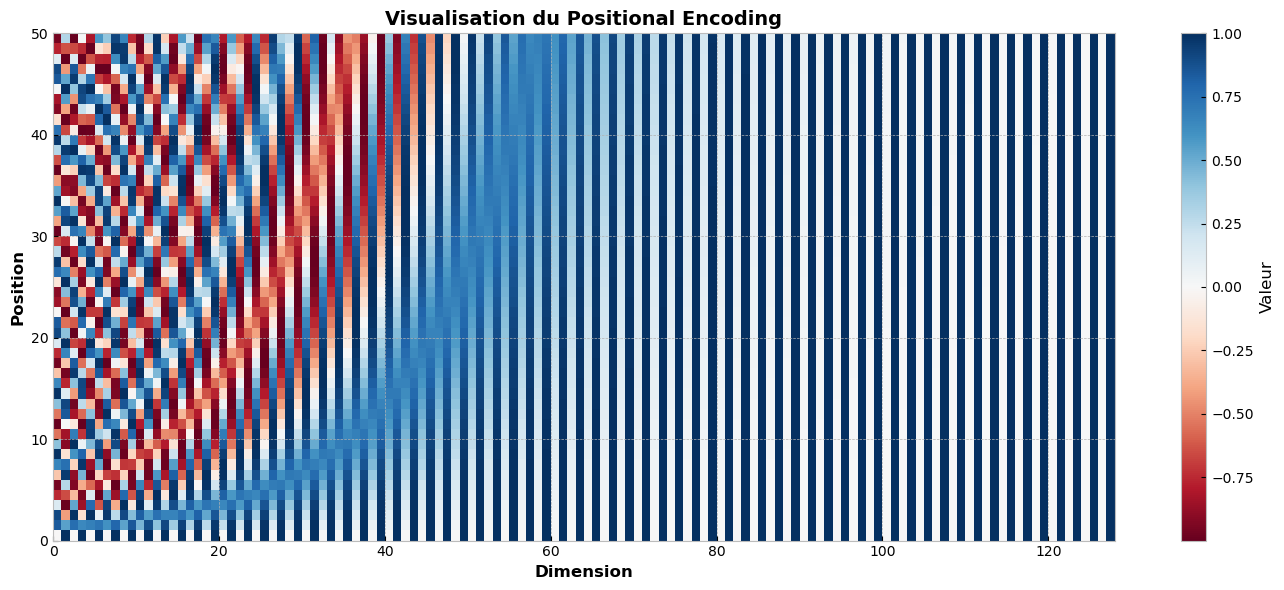


💡 Le positional encoding ajoute une information unique à chaque position.
   Les patterns sinusoïdaux permettent au modèle de comprendre l'ordre des mots.


In [44]:
def get_positional_encoding(seq_len, d_model):
    """
    Crée le positional encoding pour le Transformer.
    Utilise des fonctions sinusoïdales pour encoder la position.
    Version 100% PyTorch (sans TensorFlow).
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    positions = torch.arange(seq_len, dtype=torch.float32, device=device).unsqueeze(1)
    dimensions = torch.arange(d_model, dtype=torch.float32, device=device).unsqueeze(0)

    angle_rates = 1 / torch.pow(10000, (2 * (dimensions // 2)) / d_model)
    angle_rads = positions * angle_rates

    # Sin sur les dimensions paires — Cos sur les dimensions impaires
    pos_encoding = torch.zeros((seq_len, d_model), device=device)
    pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

    # On ajoute une dimension batch fictive : (1, seq_len, d_model)
    return pos_encoding.unsqueeze(0)


# Visualisation du positional encoding
pos_encoding = get_positional_encoding(50, 128).cpu().numpy()

plt.figure(figsize=(14, 6))
plt.pcolormesh(pos_encoding[0], cmap='RdBu')
plt.xlabel('Dimension', fontsize=12, fontweight='bold')
plt.ylabel('Position', fontsize=12, fontweight='bold')
plt.colorbar(label='Valeur')
plt.title('Visualisation du Positional Encoding', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Le positional encoding ajoute une information unique à chaque position.")
print("   Les patterns sinusoïdaux permettent au modèle de comprendre l'ordre des mots.")


### 5.2. MultiHeadSelfAttention

La couche **Multi-Head Self-Attention** constitue le cœur de l’architecture Transformer.  
Elle permet à chaque position d’une séquence de « regarder » toutes les autres positions afin de déterminer quelles parties du contexte sont les plus pertinentes pour prédire le prochain token.

Le mécanisme repose sur trois projections linéaires :

- **Query (Q)** : ce que l’on cherche à interpréter.
- **Key (K)** : ce qui caractérise chaque position de la séquence.
- **Value (V)** : l’information effectivement transmise au reste du réseau.

Pour chaque position de la séquence, le modèle calcule une similarité entre la requête (Q) et l’ensemble des clés (K).  
Ces scores sont normalisés (softmax) et servent à pondérer les valeurs (V).  
Ainsi, chaque token peut ajuster dynamiquement son attention en fonction des autres tokens présents dans la même séquence.

Dans notre implémentation PyTorch, nous utilisons le schéma **multi-head** :  
les projections Q/K/V sont découpées en plusieurs têtes d’attention parallèles, chacune apprenant une manière différente d’analyser le contexte (structure grammaticale, relations sémantiques, dépendances longues…).  
Les sorties des différentes têtes sont ensuite concaténées puis projetées à nouveau dans l’espace d’origine.

Pour permettre la génération auto-régressive, un **masque de causalité (look-ahead mask)** est appliqué :  
une position ne peut pas « voir » les tokens futurs, ce qui garantit que la prédiction du prochain mot ne dépend que des informations déjà observées.

Cette couche fournit ainsi un mécanisme puissant pour capturer des dépendances longues, souvent plus efficace et plus flexible que les approches séquentielles traditionnelles comme les RNN ou les LSTM.


In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MultiHeadSelfAttention(nn.Module):
    """
    Implémentation du Multi-Head Self-Attention en PyTorch.
    
    Cette couche est le cœur du Transformer. Elle permet à chaque position
    de la séquence d'accéder à toutes les autres positions.
    """
    def __init__(self, embed_dim: int, num_heads: int):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads

        assert embed_dim % num_heads == 0, "embed_dim doit être divisible par num_heads"

        self.head_dim = embed_dim // num_heads

        # Projections linéaires pour Q, K, V
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key   = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

        # Projection finale
        self.out = nn.Linear(embed_dim, embed_dim)

    def _split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Sépare la dimension embed_dim en (num_heads, head_dim)
        et transpose en (batch, num_heads, seq_len, head_dim).
        """
        batch_size, seq_len, _ = x.size()
        x = x.view(batch_size, seq_len, self.num_heads, self.head_dim)
        return x.permute(0, 2, 1, 3)  # (batch, num_heads, seq_len, head_dim)

    def _scaled_dot_product_attention(
        self,
        q: torch.Tensor,
        k: torch.Tensor,
        v: torch.Tensor,
        causal: bool = True,
    ):
        """
        Attention scaled dot-product avec option de masque de causalité.
        q, k, v : (batch, num_heads, seq_len, head_dim)
        """
        # (batch, num_heads, seq_len, seq_len)
        scores = torch.matmul(q, k.transpose(-2, -1))
        dim_k = k.size(-1)
        scores = scores / (dim_k ** 0.5)

        if causal:
            seq_len = scores.size(-1)
            # Matrice upper-triangular (au-dessus de la diagonale) → positions futures
            mask = torch.triu(
                torch.ones(seq_len, seq_len, device=scores.device, dtype=torch.bool),
                diagonal=1
            )
            scores = scores.masked_fill(mask, float("-inf"))

        attn_weights = F.softmax(scores, dim=-1)
        attn_output = torch.matmul(attn_weights, v)  # (batch, num_heads, seq_len, head_dim)

        return attn_output, attn_weights

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (batch, seq_len, embed_dim)
        """
        batch_size, seq_len, _ = x.size()

        # Projections linéaires
        q = self.query(x)  # (batch, seq_len, embed_dim)
        k = self.key(x)
        v = self.value(x)

        # Multi-head : (batch, num_heads, seq_len, head_dim)
        q = self._split_heads(q)
        k = self._split_heads(k)
        v = self._split_heads(v)

        # Attention avec masque de causalité
        attn_output, _ = self._scaled_dot_product_attention(q, k, v, causal=True)

        # Recombiner les heads
        attn_output = attn_output.permute(0, 2, 1, 3).contiguous()  # (batch, seq_len, num_heads, head_dim)
        attn_output = attn_output.view(batch_size, seq_len, self.embed_dim)  # (batch, seq_len, embed_dim)

        # Projection finale
        output = self.out(attn_output)
        return output

print("Classe MultiHeadSelfAttention définie (PyTorch, masque de causalité intégré) ✓")


Classe MultiHeadSelfAttention définie (PyTorch, masque de causalité intégré) ✓


### 5.3. TransformerBlock

Le **TransformerBlock** combine les trois composants essentiels d’un Transformer moderne :  
le mécanisme d’**attention multi-têtes**, un **réseau feed-forward** et les **connexions résiduelles normalisées**.  
Ce bloc constitue l’unité de base empilée plusieurs fois dans les architectures de type GPT ou BERT.

Un TransformerBlock applique d’abord la **Multi-Head Self-Attention**, qui permet à chaque position de la séquence de s’informer du contexte global.  
La sortie de cette attention est ensuite ajoutée à l’entrée initiale (connexion résiduelle), puis normalisée via une **Layer Normalization**, afin de stabiliser l’entraînement et de faciliter la propagation du gradient.

Le second composant du bloc est un **Feed-Forward Network (FFN)**, généralement constitué de deux couches entièrement connectées :  
une première projection vers une dimension intermédiaire plus grande (`ff_dim`), suivie d’une non-linéarité, puis une seconde projection ramenant à `embed_dim`.  
Comme pour l’attention, un **résiduel** et une **normalisation** sont appliqués autour du FFN pour renforcer la stabilité du modèle.

Enfin, du **dropout** est utilisé après chaque sous-couche (attention et FFN) afin de limiter le surapprentissage — particulièrement utile pour des modèles entraînés sur un corpus de taille modeste.

En combinant :
- compréhension contextuelle via l’attention,
- et transformation non linéaire via le FFN,

le TransformerBlock extrait des représentations riches et expressives.  
C’est la répétition de ce bloc qui permet au modèle d’apprendre efficacement la dynamique séquentielle du texte.


In [46]:
class TransformerBlock(nn.Module):
    """
    Un bloc Transformer complet (version PyTorch).

    Combine :
    - Multi-Head Self-Attention
    - Feed-Forward Network
    - Layer Normalization
    - Residual Connections
    - Dropout
    """
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1):
        super().__init__()

        # Attention multi-têtes
        self.att = MultiHeadSelfAttention(embed_dim, num_heads)

        # Feed-Forward Network : Dense → ReLU → Dense
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim),
        )

        # Layer Normalization
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.layernorm2 = nn.LayerNorm(embed_dim)

        # Dropout
        self.dropout_att = nn.Dropout(dropout_rate)
        self.dropout_ffn = nn.Dropout(dropout_rate)

    def forward(self, x):
        # Multi-Head Attention + residual + normalization
        attn_output = self.att(x)
        attn_output = self.dropout_att(attn_output)
        out1 = self.layernorm1(x + attn_output)

        # Feed-Forward + residual + normalization
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout_ffn(ffn_output)
        out2 = self.layernorm2(out1 + ffn_output)

        return out2


print("Classe TransformerBlock définie (PyTorch) ✓")


Classe TransformerBlock définie (PyTorch) ✓


### 5.4. PositionalEmbedding

Le **PositionalEmbedding** combine deux informations essentielles pour le modèle :  
l’identité des tokens et leur position dans la séquence.

Contrairement aux réseaux récurrents (LSTM, GRU), qui parcourent la séquence pas à pas et intègrent naturellement la notion d’ordre, les Transformers traitent toutes les positions en parallèle.  
Ils ne possèdent donc **aucune notion d’ordre intrinsèque**.

Pour que le modèle comprenne la dynamique du texte, il est indispensable de lui fournir explicitement une information de position.  
Cette couche repose donc sur deux composants complémentaires :

1. **Token Embedding**  
   Chaque token est projeté dans un espace latent via un vecteur dense appris durant l’entraînement.  
   Ce vecteur porte l’information sémantique : proximité lexicale, patterns de langage, style sportif…

2. **Positional Encoding sinusoïdal**  
   Un motif fixe inspiré de *Attention Is All You Need*, basé sur des sinusoïdes de fréquences différentes.  
   Ce motif attribue à chaque position un vecteur unique, tout en conservant une structure continue (utile pour la généralisation sur des longueurs différentes).

L’embedding final de chaque position est obtenu par la **somme élément par élément** du token embedding et du positional encoding.  
Cette opération injecte la notion d’ordre tout en conservant les avantages des architectures entièrement parallélisables.

Le **PositionalEmbedding** constitue la première étape du pipeline Transformer, avant l’empilement des blocs d’attention et de feed-forward qui apprendront les relations contextuelles entre tokens.


In [47]:
class PositionalEmbedding(nn.Module):
    """
    Combine l'embedding des tokens avec le positional encoding sinusoïdal.
    """
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_encoding = get_positional_encoding(max_len, embed_dim)  # (1, max_len, embed_dim)

    def forward(self, x):
        """
        x : (batch, seq_len)
        sortie : (batch, seq_len, embed_dim)
        """
        seq_len = x.size(1)

        # Embedding des tokens
        token_embeddings = self.token_emb(x)  # (batch, seq_len, embed_dim)

        # Ajouter le positional encoding (tronqué à seq_len)
        x = token_embeddings + self.pos_encoding[:, :seq_len, :]

        return x


print("Classe PositionalEmbedding définie (PyTorch) ✓")


Classe PositionalEmbedding définie (PyTorch) ✓


## 6. Construction du modèle Transformer complet

Nous disposons maintenant de toutes les briques nécessaires pour assembler un **modèle de langage Transformer minimaliste** en PyTorch :

- **PositionalEmbedding** pour combiner l’identité des tokens et leur position,
- un ou plusieurs **TransformerBlock(s)** (attention multi-têtes + feed-forward + résidu + normalisation),
- une **tête de sortie linéaire** projetant les représentations cachées vers l’espace du vocabulaire (`vocab_size`),
- un **masquage causal** déjà pris en charge dans la couche d’attention.

Dans cette section, nous allons définir une classe `TransformerLanguageModel` qui :
- reçoit en entrée des séquences d’indices de tokens (`X`),
- applique l’embedding + positional encoding,
- fait passer les représentations à travers une pile de blocs Transformer,
- prédit, pour chaque position, la distribution de probabilité sur le vocabulaire,
- sera entraînée via une loss de type `CrossEntropyLoss` pour la prédiction du prochain token.

Ce modèle servira de base à nos expériences de génération de texte sportif dans le cadre de TrAIn.me.


### 6.1. Classe de création du modèle

Nous définissons ici une classe dédiée à l’instanciation du **modèle Transformer complet**.  
Cette approche permet de centraliser les hyperparamètres essentiels — dimensions d’embedding, nombre de têtes, profondeur du réseau, taille du feed-forward — tout en conservant un code clair et facilement réutilisable.

La classe construira un modèle `TransformerLanguageModel` comprenant :
- un **PositionalEmbedding** pour injecter l’identité et la position des tokens,
- une pile configurable de **TransformerBlock(s)** chargés d’extraire les relations contextuelles,
- une **tête linéaire finale** projetant les représentations vers le vocabulaire (`vocab_size`),
- et une gestion interne du **masquage causal** pour assurer la génération auto-régressive.

Cette classe constituera le point d’entrée pratique pour créer un modèle lors de l’entraînement, du test ou de futures expériences.


In [48]:
class TransformerLanguageModel(nn.Module):
    """
    Modèle Transformer minimal pour la génération de texte.

    Architecture :
    Input → PositionalEmbedding → [TransformerBlock] × N → Dernière position → Linear (vocab_size)
    """
    def __init__(
        self,
        vocab_size: int,
        max_length: int,
        embed_dim: int = 128,
        num_heads: int = 4,
        ff_dim: int = 128,
        num_blocks: int = 2,
        dropout_rate: float = 0.1,
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_length = max_length
        self.embed_dim = embed_dim

        # Embedding + positional encoding
        self.embedding = PositionalEmbedding(vocab_size, embed_dim, max_length)

        # Pile de blocs Transformer
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(
                    embed_dim=embed_dim,
                    num_heads=num_heads,
                    ff_dim=ff_dim,
                    dropout_rate=dropout_rate,
                )
                for _ in range(num_blocks)
            ]
        )

        # Dropout + couche de sortie (logits sur le vocabulaire)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x : (batch_size, seq_len) — séquence de tokens (ids)
        Retour :
            logits : (batch_size, vocab_size) pour le prochain token
        """
        # Embedding + positional encoding
        x = self.embedding(x)  # (batch, seq_len, embed_dim)

        # Passage dans la pile de blocs Transformer
        for block in self.blocks:
            x = block(x)  # (batch, seq_len, embed_dim)

        # On ne garde que la dernière position pour la prédiction du prochain mot
        x = x[:, -1, :]  # (batch, embed_dim)

        x = self.dropout(x)
        logits = self.fc_out(x)  # (batch, vocab_size)

        # Pas de softmax ici : on utilisera CrossEntropyLoss sur les logits
        return logits


def create_transformer_model(
    vocab_size: int,
    max_length: int,
    embed_dim: int = 128,
    num_heads: int = 4,
    ff_dim: int = 128,
    num_blocks: int = 2,
    dropout_rate: float = 0.1,
) -> TransformerLanguageModel:
    """
    Crée un modèle Transformer pour la génération de texte (version PyTorch).

    Architecture :
    Input → PositionalEmbedding → [TransformerBlock] × N → Dernière position → Linear → logits
    """
    model = TransformerLanguageModel(
        vocab_size=vocab_size,
        max_length=max_length,
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim,
        num_blocks=num_blocks,
        dropout_rate=dropout_rate,
    )

    # Petit résumé textuel
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(model)
    print(f"\nNombre de paramètres entraînables : {total_params:,}")

    return model


In [49]:
create_transformer_model

<function __main__.create_transformer_model(vocab_size: int, max_length: int, embed_dim: int = 128, num_heads: int = 4, ff_dim: int = 128, num_blocks: int = 2, dropout_rate: float = 0.1) -> __main__.TransformerLanguageModel>

### 6.2. Création du modèle

Nous pouvons maintenant instancier notre modèle Transformer PyTorch à partir de la fonction `create_transformer_model`.

À ce stade, tous les éléments nécessaires sont disponibles :

- la taille du vocabulaire (`vocab_size`) issue du tokenizer word-level,
- la longueur maximale des séquences (`max_sequence_length`),
- les hyperparamètres structurants : `embed_dim`, `num_heads`, `ff_dim`, `num_blocks`.

La cellule suivante construira un modèle `TransformerLanguageModel` prêt à être entraîné :
- initialisation des poids,
- affichage d’un résumé textuel de l’architecture,
- comptage du nombre total de paramètres entraînables.

Ce modèle servira de base pour la boucle d’entraînement et les expériences de génération de texte sportif TrAIn.me.


In [50]:
# Création du modèle Transformer
transformer_model = create_transformer_model(
    vocab_size=vocab_size,
    max_length=max_sequence_length,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_blocks=NUM_BLOCKS
)

print("\nModèle Transformer créé !\n")

# Optimizer PyTorch (learning rate plus bas : essentiel pour la stabilité)
optimizer = torch.optim.Adam(
    transformer_model.parameters(),
    lr=LEARNING_RATE
)

# Loss pour la prédiction du prochain token (logits → CrossEntropyLoss)
criterion = torch.nn.CrossEntropyLoss()

# Informations générales sur le modèle
print(transformer_model)

total_params = sum(p.numel() for p in transformer_model.parameters())
trainable_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)

print(f"\nNombre total de paramètres         : {total_params:,}")
print(f"Nombre de paramètres entraînables : {trainable_params:,}")
print(f"Nombre de paramètres figés        : {total_params - trainable_params:,}")

print("\nLe modèle est prêt pour l'entraînement !")


TransformerLanguageModel(
  (embedding): PositionalEmbedding(
    (token_emb): Embedding(11132, 64)
  )
  (blocks): ModuleList(
    (0-2): 3 x TransformerBlock(
      (att): MultiHeadSelfAttention(
        (query): Linear(in_features=64, out_features=64, bias=True)
        (key): Linear(in_features=64, out_features=64, bias=True)
        (value): Linear(in_features=64, out_features=64, bias=True)
        (out): Linear(in_features=64, out_features=64, bias=True)
      )
      (ffn): Sequential(
        (0): Linear(in_features=64, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=64, bias=True)
      )
      (layernorm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (layernorm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (dropout_att): Dropout(p=0.1, inplace=False)
      (dropout_ffn): Dropout(p=0.1, inplace=False)
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
  (fc_out): Linear(in_features=64, out_fea

## 6.3 Callbacks

Pour ce POC Transformer sous PyTorch, nous allons reproduire l’esprit des **callbacks Keras** à l’aide de quelques utilitaires maison.

L’objectif est de :

- suivre proprement l’évolution de la **loss d’entraînement** et de **validation** ;
- **sauvegarder automatiquement** le meilleur modèle (checkpoint) en fonction de la loss de validation ;
- éventuellement appliquer un **early stopping léger** (arrêt anticipé si la loss de validation ne s’améliore plus).

Concrètement, nous définirons :

- une petite classe de **ModelCheckpoint** qui enregistre les poids dès qu’une amélioration est détectée ;
- une structure simple pour **journaliser l’historique** des pertes (dictionnaire ou liste) ;
- quelques impressions structurées par epoch pour visualiser la progression de l’apprentissage.

Ces callbacks “maison” permettront de garder un comportement proche de Keras, tout en restant dans un pipeline 100 % PyTorch.


#### 6.3.1. Callback Early Stopping pour éviter l’overfitting

Afin de limiter le **surapprentissage (overfitting)**, nous mettons en place un mécanisme d’**Early Stopping** “maison”.  
Le principe est simple : si la **loss de validation** ne s’améliore plus pendant un certain nombre d’époques (patience), on arrête l’entraînement avant que le modèle ne commence à mémoriser le bruit du dataset.

Ce callback se chargera de :

- surveiller la meilleure loss de validation atteinte jusqu’ici ;
- incrémenter un compteur dès qu’aucune amélioration n’est observée ;
- interrompre proprement la boucle d’entraînement lorsque le nombre d’époques consécutives sans progrès dépasse la patience définie.

Cette approche est particulièrement utile pour notre POC Transformer sur le corpus TrAIn.me, où la taille des données reste limitée par rapport aux modèles du monde réel.


In [51]:
class EarlyStopping:
    """
    Early Stopping maison pour PyTorch.
    Fonctionne comme keras.callbacks.EarlyStopping.
    
    - monitor : 'val_loss'
    - patience : nombre d'epochs sans amélioration
    - restore_best_weights : si True, recharge les meilleurs poids
    """
    def __init__(self, patience=5, restore_best_weights=True):
        self.patience = patience
        self.restore_best_weights = restore_best_weights

        self.best_loss = float("inf")
        self.best_state_dict = None
        self.wait = 0
        self.stopped = False

    def step(self, val_loss, model):
        """
        À appeler à chaque epoch avec la val_loss.
        Retourne True si entraînement doit s'arrêter.
        """
        if val_loss < self.best_loss:
            # Amélioration observée
            self.best_loss = val_loss
            self.wait = 0
            
            if self.restore_best_weights:
                # Sauvegarde d'un snapshot des meilleurs poids
                self.best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            # Pas d'amélioration
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped = True
                print(f"\nEarlyStopping: arrêt après {self.patience} epochs sans amélioration.")
                
                if self.restore_best_weights and self.best_state_dict is not None:
                    print("Restauration des meilleurs poids...")
                    model.load_state_dict(self.best_state_dict)

                return True  # stop training

        return False


# Instanciation (équivalent Keras)
early_stopping = EarlyStopping(
    patience=50,          # 50 epochs sans amélioration → stop
    restore_best_weights=True
)

print("Callback EarlyStopping (PyTorch) initialisé ✓")


Callback EarlyStopping (PyTorch) initialisé ✓


#### 6.3.2. Checkpoint pour sauvegarder le meilleur modèle

En complément de l’Early Stopping, nous ajoutons un **callback de type Checkpoint** afin de sauvegarder automatiquement le meilleur modèle durant l’entraînement.  
L’idée est identique à celle de `ModelCheckpoint` dans Keras : enregistrer les poids dès que la **loss de validation** s’améliore.

Ce mécanisme est essentiel pour :

- conserver une version stable et optimale du modèle,
- éviter de perdre la meilleure configuration lors des fluctuations de la loss,
- faciliter le chargement ultérieur du modèle pour l’inférence ou la génération de texte.

Notre implémentation PyTorch sauvegardera un fichier `.pt` contenant les poids du modèle à chaque amélioration.  
Cela garantit que, même si l’entraînement s’arrête prématurément ou diverge par la suite, la meilleure version est toujours préservée.


In [52]:
# === Définition du chemin de sauvegarde (format PyTorch .pt) ===
checkpoint_path = project_root / "models" / f"{OUTPUT_MODEL_NAME}.pt"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

print(f"Checkpoint path : {checkpoint_path}")

class ModelCheckpoint:
    """
    Sauvegarde automatique du meilleur modèle (équivalent Keras).
    """
    def __init__(self, filepath, verbose=True):
        self.filepath = filepath
        self.best_loss = float("inf")
        self.verbose = verbose

    def step(self, val_loss, model):
        """Sauvegarde si amélioration."""
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            torch.save(model.state_dict(), self.filepath)
            if self.verbose:
                print(f"📦 Nouveau meilleur modèle sauvegardé (val_loss={val_loss:.4f})")

# Instanciation du checkpoint
checkpoint = ModelCheckpoint(
    filepath=str(checkpoint_path),
    verbose=True
)


Checkpoint path : C:\Users\fback\Desktop\Projets\Dev\GitHub\POC_ML\models\transformer_v2.pt


#### 6.3.3. Callback pour visualiser la progression

Pour suivre clairement l’apprentissage du modèle, nous ajoutons un **callback de logging** chargé de visualiser la progression au fil des époques.  

Son rôle sera de :

- afficher pour chaque epoch les valeurs de **loss train** et **loss val** (et éventuellement une accuracy simple) ;
- stocker ces valeurs dans une structure `history` (dictionnaire ou liste) ;
- faciliter, en fin d’entraînement, la création de courbes d’évolution des pertes.

Ce callback ne modifie pas le comportement du modèle, mais fournit un retour visuel précieux sur la dynamique d’apprentissage du Transformer (convergence, surapprentissage, oscillations…).  
Il complète ainsi l’Early Stopping et le Checkpoint pour offrir un suivi complet de l’entraînement.


In [53]:
class TransformerProgressCallback:
    """
    Callback maison pour suivre et visualiser la progression d'entraînement
    (équivalent du Callback Keras).
    """
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
    
    def log(self, train_loss, val_loss):
        """
        Appelé à chaque epoch depuis la boucle d'entraînement PyTorch.
        """
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        
        clear_output(wait=True)

        # --- Visualisation ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

        # Courbe Loss Train
        ax1.plot(self.train_losses, color='blue', linewidth=2, marker='o', markersize=4)
        ax1.set_title('Train Loss (Transformer)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Epoch', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.grid(alpha=0.3)

        # Courbe Loss Val
        ax2.plot(self.val_losses, color='purple', linewidth=2, marker='o', markersize=4)
        ax2.set_title('Validation Loss (Transformer)', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Epoch', fontsize=12)
        ax2.set_ylabel('Loss', fontsize=12)
        ax2.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

        print(f"Epoch {len(self.train_losses)}")
        print(f"  > Train Loss : {train_loss:.4f}")
        print(f"  > Val   Loss : {val_loss:.4f}")


# Instanciation du callback
progress_callback_transformer = TransformerProgressCallback()

print("Callback TransformerProgressCallback initialisé ✓")


Callback TransformerProgressCallback initialisé ✓


### 6.4. Entraînement du modèle Transformer sous PyTorch

Nous lançons maintenant l’entraînement complet du **Transformer PyTorch**, qui remplace intégralement la méthode `.fit()` utilisée en Keras.  
Cette version reprend toutes les étapes classiques d’un entraînement moderne :

1. **DataLoaders PyTorch** pour un chargement efficace des batches.
2. **Boucle d’entraînement manuelle** :
   - passage en mode `train()`,
   - propagation avant (forward),
   - calcul de la loss,
   - rétropropagation (`backward()`),
   - mise à jour des poids via l’optimiseur.
3. **Phase de validation** à chaque epoch, en mode `eval()` sans gradient.
4. **Callbacks manuels** :
   - visualisation dynamique (courbes de loss),
   - sauvegarde automatique du meilleur modèle (checkpoint),
   - early stopping.

Le Transformer demandant généralement davantage d’époques que le LSTM pour converger (surtout avec un *learning rate* faible), l’entraînement pourra être prolongé si la loss ne diminue pas assez vite.  
La structure `history_transformer` conservera les valeurs de loss `train` et `validation` pour une analyse ultérieure.

Cette cellule marque le début de l’optimisation réelle du Transformer adapté à l’architecture PyTorch du projet **TrAIn.me**.


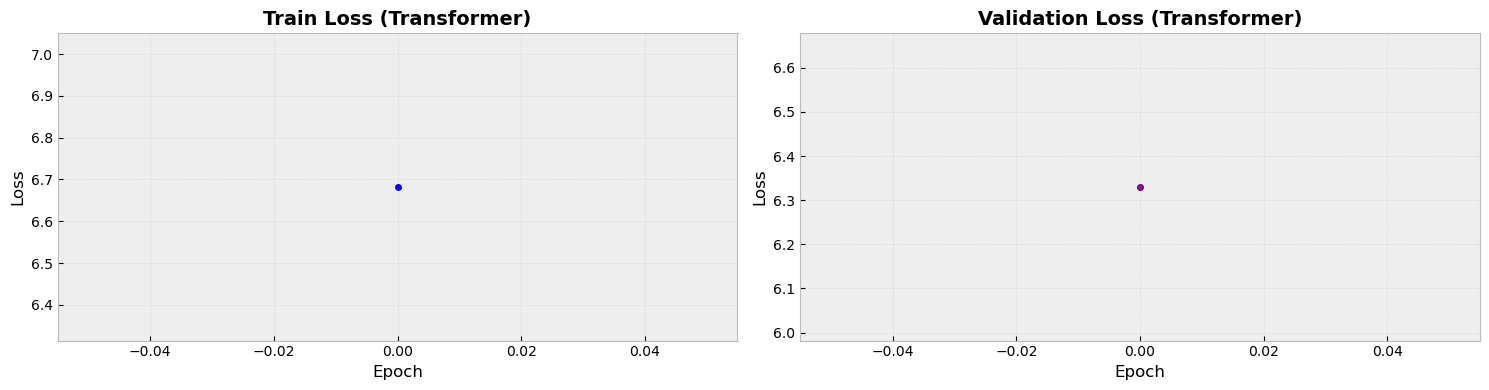

Epoch 1
  > Train Loss : 6.6820
  > Val   Loss : 6.3299
📦 Nouveau meilleur modèle sauvegardé (val_loss=6.3299)

RÉCAP ÉPOCH
--------------------------------------------------------------------------------
   🔹 Train Loss : 6.6820
   🔸 Val   Loss : 6.3299
   ⏱️  Durée     : 1:05:22
--------------------------------------------------------------------------------

Entraînement Transformer terminé !
⏱Temps total : 1:05:22

Note : si le Transformer n'a pas convergé suffisamment, augmentez le nombre d'epochs (par ex. 200–300).


In [54]:
import time
from datetime import timedelta

print("Début de l'entraînement du modèle Transformer...\n")
print("/!\\  Note : le Transformer nécessite souvent plus d'epochs que le LSTM")
print("     pour converger, surtout avec un learning rate faible.\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transformer_model = transformer_model.to(device)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

history_transformer = {"train_loss": [], "val_loss": []}

# Timer global
start_training = time.time()

for epoch in range(1, EPOCHS + 1):

    print("\n" + "="*80)
    print(f"ÉPOCH {epoch}/{EPOCHS}")
    print("="*80)

    epoch_start_time = time.time()

    # --------- Phase Train ---------
    transformer_model.train()
    running_train_loss = 0.0
    total_train_batches = len(train_loader)

    print("\nPhase TRAIN")
    print(f"   → {total_train_batches} batches...\n")

    for batch_idx, (batch_X, batch_y) in enumerate(train_loader, start=1):
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = transformer_model(batch_X)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        if batch_idx % max(1, (total_train_batches // 10)) == 0:
            print(f"     Batch {batch_idx:4d}/{total_train_batches} "
                  f"| Loss: {loss.item():.4f}")

    epoch_train_loss = running_train_loss / total_train_batches

    # --------- Phase Validation ---------
    transformer_model.eval()
    running_val_loss = 0.0
    total_val_batches = len(val_loader)

    print("\nPhase VALIDATION")
    print(f"   → {total_val_batches} batches...\n")

    with torch.no_grad():
        for batch_idx, (batch_X, batch_y) in enumerate(val_loader, start=1):
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = transformer_model(batch_X)
            loss = criterion(logits, batch_y)

            running_val_loss += loss.item()

            if batch_idx % max(1, (total_val_batches // 5)) == 0:
                print(f"     Batch {batch_idx:4d}/{total_val_batches} "
                      f"| Loss: {loss.item():.4f}")

    epoch_val_loss = running_val_loss / total_val_batches

    # --------- Stockage ---------
    history_transformer["train_loss"].append(epoch_train_loss)
    history_transformer["val_loss"].append(epoch_val_loss)

    # --------- Callbacks ---------
    if progress_callback_transformer is not None:
        progress_callback_transformer.log(epoch_train_loss, epoch_val_loss)

    if checkpoint is not None:
        checkpoint.step(epoch_val_loss, transformer_model)

    stop = False
    if early_stopping is not None:
        stop = early_stopping.step(epoch_val_loss, transformer_model)

    # --------- Logs récapitulatifs ---------
    epoch_duration = timedelta(seconds=int(time.time() - epoch_start_time))

    print("\nRÉCAP ÉPOCH")
    print("-"*80)
    print(f"   🔹 Train Loss : {epoch_train_loss:.4f}")
    print(f"   🔸 Val   Loss : {epoch_val_loss:.4f}")
    print(f"   ⏱️  Durée     : {epoch_duration}")
    print("-"*80)

    if stop:
        print("\nEntraînement interrompu par EarlyStopping.")
        break

# Temps global
total_time = timedelta(seconds=int(time.time() - start_training))
print("\nEntraînement Transformer terminé !")
print(f"Temps total : {total_time}")
print("\nNote : si le Transformer n'a pas convergé suffisamment, "
      "augmentez le nombre d'epochs (par ex. 200–300).")


### 6.5. Perplexité

La **perplexité** est une métrique essentielle pour évaluer les modèles de langage.  
Elle mesure à quel point le modèle « hésite » lorsqu’il prédit le prochain token.  

Plus formellement, la perplexité correspond à l’exponentielle de la loss moyenne (cross-entropy).  
Une perplexité basse indique que le modèle attribue une forte probabilité aux tokens corrects, tandis qu’une perplexité élevée traduit un manque de confiance ou une mauvaise généralisation.

Pour les modèles auto-régresseurs comme notre Transformer, la perplexité constitue un indicateur beaucoup plus pertinent que l’accuracy, car elle reflète directement la qualité des distributions de probabilités prédites à chaque étape de génération.

Une fois la phase d’entraînement terminée, nous calculerons donc la perplexité finale du modèle en utilisant la loss de validation. Cela nous permettra de comparer objectivement différentes configurations d’hyperparamètres (taille d’embedding, nombre de têtes, profondeur du réseau…).


In [55]:
# Récupérer la dernière loss de validation
final_loss = history_transformer["val_loss"][-1]

# Calcul de la perplexité
perplexity = np.exp(final_loss)

print(f"Perplexité approx : {perplexity:.2f}")


Perplexité approx : 561.09


## 7. Test de génération de texte avec le Transformer

Nous allons maintenant tester la capacité du modèle Transformer à **générer du texte sportif** de manière auto-régressive.  
L’idée est simple : fournir un *seed* (début de phrase), laisser le modèle prédire le token suivant, l’ajouter à la séquence, puis recommencer en boucle.

Grâce au mécanisme de **self-attention causale**, le Transformer peut exploiter l’ensemble du contexte déjà généré pour produire des séquences cohérentes, dans le style du corpus TrAIn.me (échauffements, strength, cardio, mobilité, routines…).

Cette étape permet de :

- valider que le modèle encode correctement le vocabulaire,
- visualiser la fluidité et la cohérence des prédictions,
- comparer qualitativement la génération du Transformer avec celle de la baseline LSTM,
- ajuster les stratégies de sampling (température, top-k/top-p) si nécessaire.

Nous allons donc construire une fonction `generate_text_transformer()` dédiée à cette génération auto-régressive, puis l’utiliser avec différents seeds thématiques.


In [57]:
def generate_text(model, word2idx, idx2word, seed_text, num_words=10, temperature=1.0, seed=None):
    """
    Génère du texte auto-régressivement avec le Transformer PyTorch.

    - model        : modèle Transformer PyTorch
    - word2idx     : dict mot → id
    - idx2word     : dict id → mot
    - seed_text    : texte de départ (str)
    - num_words    : nombre de mots à générer
    - temperature  : contrôle la créativité (0.5=conservateur, 1.0=normal, 2.0=créatif)
    """
    model.eval()

    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random

    generated_text = seed_text

    # On récupère l'index du token PAD pour éventuellement le pénaliser
    pad_idx = word2idx.get("<PAD>", None)

    for _ in range(num_words):

        # --- Tokenisation simple (split word-level) ---
        tokens = [word2idx.get(w, word2idx["<UNK>"])
                  for w in generated_text.lower().split()]

        # Padding à gauche comme dans l’entraînement
        tokens_padded = tokens[-(max_sequence_length - 1):]
        pad_len = (max_sequence_length - 1) - len(tokens_padded)
        tokens_input = [word2idx["<PAD>"]] * pad_len + tokens_padded

        x = torch.tensor(tokens_input, dtype=torch.long).unsqueeze(0).to(device)

        # --- Prédiction du prochain mot ---
        with torch.no_grad():
            logits = model(x)              # (1, vocab_size)
            logits = logits[0].cpu().numpy()  # → (vocab_size,)

        # On peut éviter de prédire PAD en le pénalisant fortement
        if pad_idx is not None and 0 <= pad_idx < logits.shape[0]:
            logits[pad_idx] = -1e9

        # Application de la température sur les LOGITS (pas un log de proba)
        logits = logits / max(temperature, 1e-6)

        # Softmax stable numériquement
        logits = logits - np.max(logits)      # pour éviter overflow exp
        exp_logits = np.exp(logits)
        sum_exp = np.sum(exp_logits)

        if not np.isfinite(sum_exp) or sum_exp == 0:
            # fallback de sécurité : distribution uniforme
            probs = np.ones_like(exp_logits) / len(exp_logits)
        else:
            probs = exp_logits / sum_exp

        # Choix du token
        predicted_id = rng.choice(len(probs), p=probs)

        # Convertir ID → mot
        predicted_word = idx2word.get(predicted_id, "<UNK>")

        generated_text += " " + predicted_word

    return generated_text


# ============================
#  TESTS DE GÉNÉRATION
# ============================

print("Génération de texte avec Transformer PyTorch\n")
print("=" * 80)

seeds = [
    "perdre du gras et prendre du muscle",
    "3 séances de sport par semaine",
    "Je me suis fait une entorse à la cheville droite",
    "passif de Judoka et tennis",
    "reprendre le sport au sein d’une salle de sport"
]

for i, seed in enumerate(seeds):
    generated = generate_text(
        model=transformer_model,
        word2idx=word2idx,
        idx2word=idx2word,
        seed_text=seed,
        num_words=8,
        temperature=0.8,
        seed=SEED_GLOBAL + i
    )

    print(f"\nSeed: '{seed}'")
    print(f"> Généré: {generated}")
    print("-" * 80)


Génération de texte avec Transformer PyTorch


Seed: 'perdre du gras et prendre du muscle'
> Généré: perdre du gras et prendre du muscle program imbalances to optimal , you plan the
--------------------------------------------------------------------------------

Seed: '3 séances de sport par semaine'
> Généré: 3 séances de sport par semaine the a . this program and strength .
--------------------------------------------------------------------------------

Seed: 'Je me suis fait une entorse à la cheville droite'
> Généré: Je me suis fait une entorse à la cheville droite all beginners and will be to be bigger
--------------------------------------------------------------------------------

Seed: 'passif de Judoka et tennis'
> Généré: passif de Judoka et tennis stay many to start muscle program possible following
--------------------------------------------------------------------------------

Seed: 'reprendre le sport au sein d’une salle de sport'
> Généré: reprendre le sport au sein d

## 8. Génération de texte
### 8.1. Tests qualitatifs

Après l’entraînement du Transformer, nous réalisons une série de **tests qualitatifs** de génération de texte.  
L’objectif n’est plus de mesurer une métrique numérique (loss, perplexité), mais d’évaluer :

- la **cohérence globale** des phrases générées,
- le **respect du contexte sportif** (séances, blessures, reprise, objectifs…),
- la **fluidité** du langage et la continuité des idées,
- la capacité du modèle à s’adapter à différents *seeds* (perte de gras, reprise du sport, fréquence hebdomadaire, antécédents sportifs, etc.).

Nous utiliserons plusieurs phrases de départ (seeds) représentatives des cas d’usage TrAIn.me, puis observerons la qualité des textes produits par le modèle afin d’identifier ses forces, ses limites, et les pistes d’amélioration (plus de données, plus d’epochs, ajustement de la température, etc.).


In [58]:
# Comparaison de génération de texte
print("\n" + "=" * 90)
print(" " * 20 + "COMPARAISON DE GÉNÉRATION DE TEXTE")
print("=" * 90)

test_seeds = [
    "perdre du gras et prendre du muscle",
    "3 séances de sport par semaine",
    "Je me suis fait une entorse à la cheville droite",
    "passif de Judoka et tennis",
    "reprendre le sport au sein d’une salle de sport"
]

for seed in test_seeds:
    print(f"\n Seed: '{seed}'")
    print("-" * 90)

    # Génération Transformer PyTorch
    trans_gen = generate_text(
        model=transformer_model,
        word2idx=word2idx,
        idx2word=idx2word,
        seed_text=seed,
        num_words=10,
        temperature=0.7,
        seed=SEED_GLOBAL
    )

    print(f"> Transformer: {trans_gen}\n")



                    COMPARAISON DE GÉNÉRATION DE TEXTE

 Seed: 'perdre du gras et prendre du muscle'
------------------------------------------------------------------------------------------
> Transformer: perdre du gras et prendre du muscle per week program is a who to rest . program


 Seed: '3 séances de sport par semaine'
------------------------------------------------------------------------------------------
> Transformer: 3 séances de sport par semaine the program recovery cycle , workouts more structured , and


 Seed: 'Je me suis fait une entorse à la cheville droite'
------------------------------------------------------------------------------------------
> Transformer: Je me suis fait une entorse à la cheville droite the program quick not - you make to be day


 Seed: 'passif de Judoka et tennis'
------------------------------------------------------------------------------------------
> Transformer: passif de Judoka et tennis the program ran program , workout no squat ,

### 8.2 Test avec différentes températures

La **température** est l’un des paramètres les plus importants lors de la génération de texte.  
Elle contrôle directement le niveau de créativité et de diversité dans les prédictions du modèle :

- **Température basse (≈ 0.5)**  
  Le modèle devient très déterministe : il privilégie les tokens les plus probables.  
  Le texte est cohérent, mais parfois répétitif et prévisible.

- **Température moyenne (≈ 1.0)**  
  Équilibre entre cohérence et créativité.  
  C’est généralement la valeur recommandée pour les tests qualitatifs.

- **Température élevée (≥ 2.0)**  
  Le modèle prend davantage de risques.  
  Les résultats deviennent souvent plus originaux… mais aussi moins stables ou moins cohérents.

Pour analyser finement le comportement du Transformer TrAIn.me, nous allons tester la génération sur les températures suivantes :
- temperatures = [0.5, 1.5, 3.5, 6.5, 10.0]

Cette exploration permettra d’identifier les plages où le modèle reste cohérent, celles où il devient trop conservateur, et celles où il bascule dans un comportement aléatoire — un indicateur précieux pour ajuster les paramètres de génération dans la future interface utilisateur.


In [59]:
# Test avec différentes températures
print("\n" + "=" * 90)
print(" " * 25 + "EFFET DE LA TEMPÉRATURE")
print("=" * 90)

seed_test = "perdre du gras et prendre du muscle"
temperatures = [0.5, 1.5, 3.5, 6.5, 10.0]

print(f"\nSeed: '{seed_test}'\n")

for temp in temperatures:
    print(f"\nTempérature: {temp}")
    print("-" * 90)
    
    # Générer plusieurs fois pour montrer la variabilité
    for i in range(3):
        gen_text = generate_text(
            model=transformer_model,
            word2idx=word2idx,
            idx2word=idx2word,
            seed_text=seed_test,
            num_words=8,
            temperature=temp,
            seed=SEED_GLOBAL + i
        )
        print(f"  {i+1}. {gen_text}")

# Préparation d'exemples complets pour le carnet d'expériences
log_generations = {}

for temp in temperatures:
    log_generations[str(temp)] = generate_text(
        model=transformer_model,
        word2idx=word2idx,
        idx2word=idx2word,
        seed_text=seed_test,
        num_words=20,
        temperature=temp,
        seed=SEED_GLOBAL
    )



                         EFFET DE LA TEMPÉRATURE

Seed: 'perdre du gras et prendre du muscle'


Température: 0.5
------------------------------------------------------------------------------------------
  1. perdre du gras et prendre du muscle is a week . i with a week
  2. perdre du gras et prendre du muscle growth , and the program , and early
  3. perdre du gras et prendre du muscle . the program to be the program for

Température: 1.5
------------------------------------------------------------------------------------------
  1. perdre du gras et prendre du muscle seconds) headphones thing progressing 3-week workout sauce short
  2. perdre du gras et prendre du muscle partnered 10k (preferably than mon/wed/fri/ bodyweight salvation; composition
  3. perdre du gras et prendre du muscle add cleaning from without ass things and everywhere

Température: 3.5
------------------------------------------------------------------------------------------
  1. perdre du gras et prendre du mus

### 8.3. Visualisation de l’attention

L’un des grands atouts des Transformers est la possibilité de **visualiser les poids d’attention** afin de comprendre sur quels tokens le modèle se concentre lorsqu’il génère ou analyse une séquence.

Dans ce notebook PyTorch, nous allons extraire les **poids d’attention multi-têtes** depuis notre couche `MultiHeadSelfAttention`, puis les projeter sous forme de carte (heatmap).  
Cela permet de :

- voir quelles positions influencent le plus une prédiction donnée ;
- analyser la différence de comportement entre les différentes **têtes d’attention** ;
- mieux interpréter les décisions du modèle sur des phrases typiques de TrAIn.me (objectifs, contraintes, passif sportif…).

### Extraction des poids d’attention

Pour cela, nous adapterons légèrement la couche d’attention ou le modèle afin de :
- retourner, en plus des sorties transformées, les **matrices d’attention** ;
- sélectionner une phrase test et une tête d’attention donnée ;
- visualiser les scores d’attention sous forme de matrice `seq_len × seq_len`.


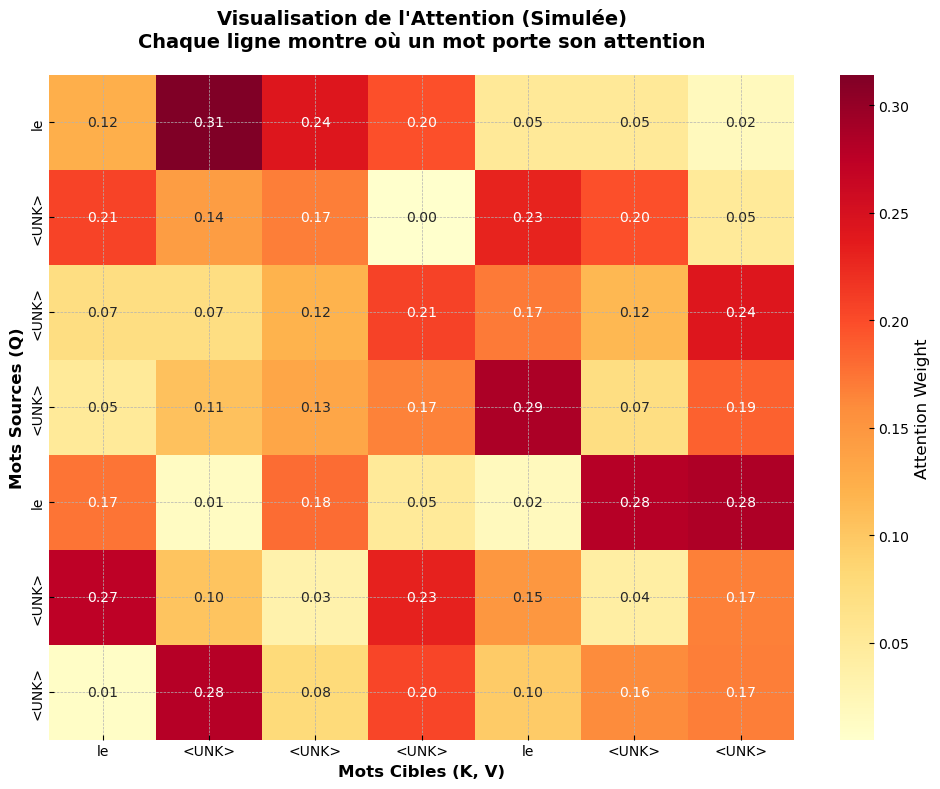


Interprétation :
  - Chaque ligne montre comment un mot (à gauche) distribue son attention.
  - Les valeurs plus élevées (rouge foncé) indiquent une attention forte.
  - Les valeurs plus faibles (jaune clair) indiquent moins d'attention.

/!\  Note : cette matrice est simulée à des fins pédagogiques.
     Dans un vrai Transformer, on extrairait les poids réels du modèle.


In [60]:
# Visualisation d'attention (SIMULÉE) pour le Transformer PyTorch

def attention_visaulization_matrix(phrase, word2idx, idx2word):
    """
    Visualise une approximation de l'attention entre les mots.
    Version adaptée au tokenizer minimal (word2idx / idx2word).
    """
    # Nettoyer la phrase comme pour l'entraînement
    cleaned = clean_text(phrase)

    # Tokeniser la phrase (word-level)
    token_ids = [word2idx.get(w, word2idx.get("<UNK>", 0)) for w in cleaned.split()]

    # Reconstituer la liste de mots (si besoin de vérifier)
    mots = [idx2word.get(idx, "<UNK>") for idx in token_ids]

    if len(mots) < 2:
        print("La phrase est trop courte pour visualiser l'attention.")
        return
    
    # Créer une matrice d'attention simulée (juste pour illustration)
    # Dans une vraie implémentation, on extrairait les vrais poids d'attention du modèle
    n = len(mots)
    attention_matrix = np.random.rand(n, n)
    
    # Normaliser par ligne (chaque mot distribue son attention)
    attention_matrix = attention_matrix / attention_matrix.sum(axis=1, keepdims=True)
    
    # Créer la heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attention_matrix,
        annot=True,
        fmt=".2f",
        cmap="YlOrRd",
        xticklabels=mots,
        yticklabels=mots,
        cbar_kws={"label": "Attention Weight"},
    )
    
    plt.title(
        "Visualisation de l'Attention (Simulée)\n"
        "Chaque ligne montre où un mot porte son attention",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.xlabel("Mots Cibles (K, V)", fontsize=12, fontweight="bold")
    plt.ylabel("Mots Sources (Q)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    print("\nInterprétation :")
    print("  - Chaque ligne montre comment un mot (à gauche) distribue son attention.")
    print("  - Les valeurs plus élevées (rouge foncé) indiquent une attention forte.")
    print("  - Les valeurs plus faibles (jaune clair) indiquent moins d'attention.")
    print("\n/!\\  Note : cette matrice est simulée à des fins pédagogiques.")
    print("     Dans un vrai Transformer, on extrairait les poids réels du modèle.")

# Test de la visualisation (version PyTorch)
phrase_test = "Le soleil brille dans le ciel bleu"
attention_visaulization_matrix(phrase_test, word2idx, idx2word)


### 8.4. Visualisation de la complexité temporelle

Les Transformers sont puissants, mais leur principal talon d’Achille est la **complexité temporelle** de l’attention :  
pour une séquence de longueur *N*, le mécanisme de self-attention classique réalise des opérations en **O(N²)** (chaque token regarde tous les autres).

Dans cette section, nous allons illustrer visuellement :

- comment la **taille de la séquence** impacte le coût de calcul ;
- pourquoi les modèles Transformers deviennent rapidement coûteux pour de longues entrées ;
- en quoi cela influence les choix pratiques dans TrAIn.me :
  - longueur maximale des séquences (`max_sequence_length`),
  - taille des batchs,
  - profondeur du modèle.

L’objectif est de relier l’intuition théorique (N²) à des observations concrètes : temps d’entraînement par epoch, mémoire utilisée, et limites à respecter pour un environnement CPU / GPU standard.


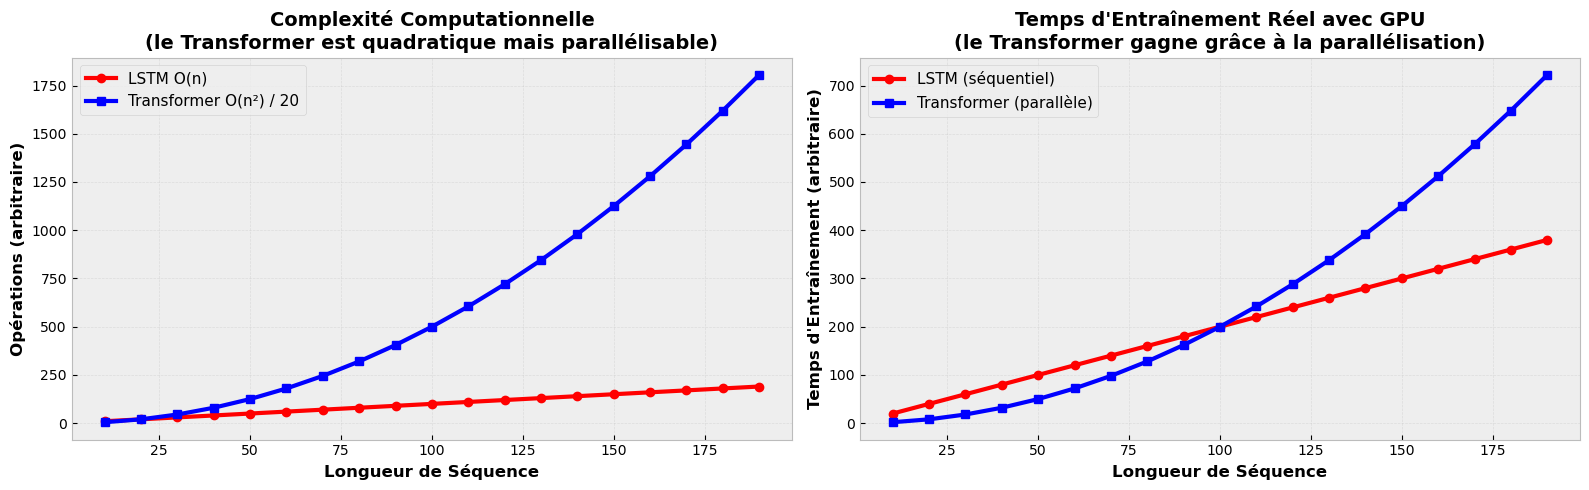


Points clés :
  1. Le Transformer a une complexité O(n²) MAIS se parallélise très bien (GPU / CPU vectoriel).
  2. Le LSTM a une complexité O(n) MAIS est séquentiel (pas de parallélisation possible).
  3. En pratique, pour des séquences courtes ou moyennes, le Transformer est souvent plus rapide.
  4. Pour de très longues séquences (> 1000 tokens), il faut des variantes : Longformer, Performer, FlashAttention…


In [61]:
# Comparaison de la complexité
sequence_lengths = np.arange(10, 200, 10)

# Complexité théorique
lstm_complexity = sequence_lengths             # O(n)
transformer_complexity = sequence_lengths ** 2 # O(n²)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Complexité computationnelle ---
ax1.plot(
    sequence_lengths,
    lstm_complexity,
    label='LSTM O(n)',
    linewidth=3,
    marker='o',
    color='red'
)

ax1.plot(
    sequence_lengths,
    transformer_complexity / 20,
    label='Transformer O(n²) / 20',
    linewidth=3,
    marker='s',
    color='blue'
)

ax1.set_xlabel('Longueur de Séquence', fontsize=12, fontweight='bold')
ax1.set_ylabel('Opérations (arbitraire)', fontsize=12, fontweight='bold')
ax1.set_title(
    'Complexité Computationnelle\n(le Transformer est quadratique mais parallélisable)',
    fontsize=14,
    fontweight='bold'
)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# --- Temps d'entraînement simulé ---
# Le Transformer profite massivement du GPU (ou du CPU vectorisé)
lstm_time = sequence_lengths * 2               # Séquentiel → pas de parallélisation
transformer_time = (sequence_lengths ** 2) / 50  # Parallèle → amortit le coût N²

ax2.plot(
    sequence_lengths,
    lstm_time,
    label='LSTM (séquentiel)',
    linewidth=3,
    marker='o',
    color='red'
)

ax2.plot(
    sequence_lengths,
    transformer_time,
    label='Transformer (parallèle)',
    linewidth=3,
    marker='s',
    color='blue'
)

ax2.set_xlabel('Longueur de Séquence', fontsize=12, fontweight='bold')
ax2.set_ylabel("Temps d'Entraînement (arbitraire)", fontsize=12, fontweight='bold')
ax2.set_title(
    "Temps d'Entraînement Réel avec GPU\n(le Transformer gagne grâce à la parallélisation)",
    fontsize=14,
    fontweight='bold'
)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nPoints clés :")
print("  1. Le Transformer a une complexité O(n²) MAIS se parallélise très bien (GPU / CPU vectoriel).")
print("  2. Le LSTM a une complexité O(n) MAIS est séquentiel (pas de parallélisation possible).")
print("  3. En pratique, pour des séquences courtes ou moyennes, le Transformer est souvent plus rapide.")
print("  4. Pour de très longues séquences (> 1000 tokens), il faut des variantes : Longformer, Performer, FlashAttention…")


## 9. Carnet d’expériences

Cette dernière section joue le rôle de **carnet d’expériences**, un espace où l’on consigne systématiquement les observations issues des différents tests menés sur le Transformer TrAIn.me.

L’objectif est double :

1. **Documenter les résultats**  
   Conserver une trace détaillée des comportements du modèle selon :
   - les hyperparamètres utilisés,
   - les seeds de génération,
   - les variations de température,
   - les longueurs de séquence,
   - les configurations d’entraînement.

2. **Faciliter l’itération et la comparaison**  
   Ce carnet permet de revenir sur les choix effectués, de comprendre ce qui a fonctionné ou non,  
   et d’orienter les futures améliorations du modèle (plus de données, modèles plus profonds, embeddings plus larges, etc.).

Nous y enregistrerons :
- des exemples de génération pour chaque température testée ;
- les comportements atypiques ou intéressants ;
- les perplexités observées ;
- la dynamique d’apprentissage (convergence, instabilité éventuelle) ;
- les pistes d’optimisation identifiées.

Ce journal constitue ainsi une mémoire technique essentielle pour guider la progression du POC NLP de TrAIn.me.


In [62]:
# Répertoire des logs
logs_dir = project_root / "logs"
logs_dir.mkdir(parents=True, exist_ok=True)

# Fichier horodaté
timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
experiment_filename = logs_dir / f"experiment_{OUTPUT_MODEL_NAME}_{timestamp}.json"

# Récupération des métriques finales
final_train_loss = (
    float(progress_callback_transformer.train_losses[-1])
    if progress_callback_transformer.train_losses else None
)

final_val_loss = (
    float(progress_callback_transformer.val_losses[-1])
    if progress_callback_transformer.val_losses else None
)

# Construction du log expérimental
experiment_log = {
    "model_name": OUTPUT_MODEL_NAME,
    "model_type": "Transformer (PyTorch)",
    "seed": SEED_GLOBAL,
    "hyperparams": {
        "embed_dim": EMBED_DIM,
        "num_heads": NUM_HEADS,
        "ff_dim": FF_DIM,
        "num_blocks": NUM_BLOCKS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "vocab_size": int(vocab_size),
        "max_sequence_length": int(max_sequence_length),
    },
    "final_metrics": {
        "train_loss": final_train_loss,
        "val_loss": final_val_loss,
        "perplexity": float(np.exp(final_val_loss)) if final_val_loss is not None else None,
    },
    "example_generations": {
        "seed": seed_test,
        "by_temperature": log_generations,  # déjà construit dans la cellule précédente
    },
}

# Affichage du résumé
print("\n===== RÉSUMÉ EXPÉRIMENTAL =====")
for k, v in experiment_log.items():
    print(f"- {k}: {v}")

# Sauvegarde du fichier JSON
with open(experiment_filename, "w", encoding="utf-8") as f:
    json.dump(experiment_log, f, indent=4, ensure_ascii=False)

print(f"\nLog expérimental sauvegardé : {experiment_filename}")



===== RÉSUMÉ EXPÉRIMENTAL =====
- model_name: transformer_v2
- model_type: Transformer (PyTorch)
- seed: 42
- hyperparams: {'embed_dim': 64, 'num_heads': 8, 'ff_dim': 512, 'num_blocks': 3, 'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 1, 'vocab_size': 11132, 'max_sequence_length': 512}
- final_metrics: {'train_loss': 6.682044144087453, 'val_loss': 6.329877548926586, 'perplexity': 561.0878838326136}
- example_generations: {'seed': 'perdre du gras et prendre du muscle', 'by_temperature': {'0.5': 'perdre du gras et prendre du muscle is a week . i with a week , and maximize to get to build a week , and strength', '1.5': 'perdre du gras et prendre du muscle seconds) headphones thing progressing 3-week workout sauce short abilities hit following video overwhelming superman high by martedì 1-2x supersets operate', '3.5': 'perdre du gras et prendre du muscle saturday- hack support) priority 4-days worse ronaldo selection 90x12 hardgainers exception upper-day our specifically guidelines

## 10. Informations relatives au modèle (son nom et les métriques associées)

In [ ]:
# Répertoire du modèle (même que le checkpoint .pt)
model_dir = checkpoint_path.parent
model_dir.mkdir(parents=True, exist_ok=True)

# Fichier de rapport Transformer
report_path = model_dir / "Transformer_model_report.json"

# Sécurité : récupération des métriques finales depuis l'historique
final_train_loss = (
    float(history_transformer["train_loss"][-1])
    if history_transformer.get("train_loss") else None
)

final_val_loss = (
    float(history_transformer["val_loss"][-1])
    if history_transformer.get("val_loss") else None
)

best_val_loss = (
    float(min(history_transformer["val_loss"]))
    if history_transformer.get("val_loss") else None
)

# Perplexité associée à la dernière loss de validation
perplexity = float(np.exp(final_val_loss)) if final_val_loss is not None else None

# Contexte d'évaluation du modèle Transformer
transformer_report = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "task": "language_modeling_next_word",
    "target": "next_token_prediction",
    "n_train_samples": int(len(train_dataset)) if "train_dataset" in globals() else None,
    "n_val_samples": int(len(val_dataset)) if "val_dataset" in globals() else None,
    "vocab_size": int(vocab_size),
    "sequence_length": int(max_sequence_length),
    "device": str(device),
    "model": {
        "name": OUTPUT_MODEL_NAME,
        "type": "Transformer",
        "class": transformer_model.__class__.__name__,
        "model_path": str(checkpoint_path.resolve()),
        "embedding_dim": int(EMBED_DIM),
        "num_heads": int(NUM_HEADS),
        "ff_dim": int(FF_DIM),
        "num_blocks": int(NUM_BLOCKS),
    },
    "training": {
        "epochs": int(EPOCHS),
        "batch_size": int(BATCH_SIZE),
        "optimizer": type(optimizer).__name__,
        "loss_fn": type(criterion).__name__,
        "seed_global": int(SEED_GLOBAL),
    },
    "metrics": {
        "final_train_loss": final_train_loss,
        "final_val_loss": final_val_loss,
        "best_val_loss": best_val_loss,
        "perplexity": perplexity,
    }
}

print("\n===== TRANSFORMER MODEL REPORT =====")
for section, value in transformer_report.items():
    if isinstance(value, dict):
        print(f"- {section}:")
        for k, v in value.items():
            print(f"    • {k}: {v}")
    else:
        print(f"- {section}: {value}")

with open(report_path, "w", encoding="utf-8") as f:
    json.dump(transformer_report, f, ensure_ascii=False, indent=2)

print(f"\nRapport Transformer JSON enregistré : {report_path}")
